# Exercise 14
**Cristina Correa - 1819211867**


Use different classification algorithms such as SVM and
Decision Trees and compare the performance. You can import them using the sklearn library.
More information can be found at:
- https://scikit-learn.org/stable/modules/tree.html
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

=== Logistic Regression ===
Accuracy: 0.9737
ROC AUC: 0.9974
Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
[[41  2]
 [ 1 70]]


=== Support Vector Machine ===
Accuracy: 0.9825
ROC AUC: 0.9974
Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  2]
 [ 0 71]]


=== Decision Tree ===
Accuracy: 0.9386
ROC AUC: 0.9369
Classification Report:
              preci

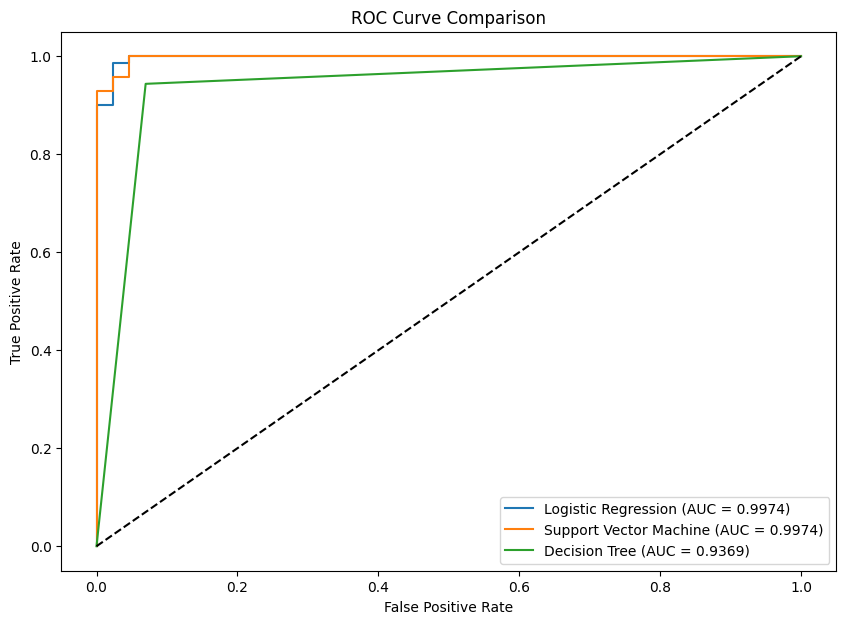

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=200),
    "Support Vector Machine": SVC(probability=True, random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
}

results = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = (
        model.predict_proba(X_test_scaled)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X_test_scaled)
    )

    accuracy = accuracy_score(y_test, y_pred)
    classification = classification_report(y_test, y_pred, target_names=target_names)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results[model_name] = {
        "Accuracy": accuracy,
        "Classification Report": classification,
        "Confusion Matrix": cm,
        "ROC AUC": roc_auc,
    }

    print(f"=== {model_name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification)
    print("Confusion Matrix:")
    print(cm)
    print("\n")

plt.figure(figsize=(10, 7))
for model_name, model in models.items():
    y_pred_proba = (
        model.predict_proba(X_test_scaled)[:, 1]
        if hasattr(model, "predict_proba")
        else model.decision_function(X_test_scaled)
    )
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(
        fpr, tpr, label=f"{model_name} (AUC = {results[model_name]['ROC AUC']:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()